# 11 — CGM Daily Means × Psychosocial Burden Tertiles

**Purpose**: Build a psychosocial burden composite from depression (CES-D),
diabetes distress (PAID-5), and discrimination score; stratify participants
into tertiles; and test whether higher psychosocial burden predicts higher
mean glucose.

**Composite**: z-score sum of `cesd_total + paid_total + discrimination_score`
(standardised individually before summing).  
Note: Notebook 06 used PCA for a similar composite. Here we use a transparent
z-score sum that is directly reproducible from the feature CSV.

**Inputs**: `features_with_cluster.csv`  
**Output**: `data/processed/11_psychosocial_tertiles_summary.csv`


In [1]:
import subprocess, sys
packages = ['scipy', 'seaborn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}

# ── Mount Google Drive (persistent across independent kernels) ────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Environment ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready.


In [2]:
features = pd.read_csv(out_dir / 'features_with_cluster.csv')

# Derive study_group_label from code if missing (e.g. stale CSV from nb07)
if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
print(f'features: {features.shape}')
print('Available columns:', features.columns.tolist())


features: (2245, 22)
Available columns: ['person_id', 'mean_glucose', 'comorbidity_cluster', 'comorbidity_index', 'study_group_code', 'cesd_total', 'paid_total', 'dml_gap_physical_activity', 'dml_gap_diet_adherence', 'dml_gap_education', 'dml_gap_foot_care', 'dml_gap_medication_mgmt', 'dml_gap_composite', 'discrimination_score', 'healthcare_access_barriers', 'food_housing_insecurity', 'neighborhood_safety_score', 'substance_exposure_count', 'otc_burden_count', 'family_risk_level', 'site_code', 'study_group_label']


## 3. Build Psychosocial Burden Composite & Tertiles

In [3]:
# ── 3a. Standardise components and sum ──────────────────────────────────
psych_components = ['cesd_total', 'paid_total', 'discrimination_score']
df = features.dropna(subset=psych_components + ['mean_glucose']).copy()

for col in psych_components:
    mu, sigma = df[col].mean(), df[col].std()
    df[f'{col}_z'] = (df[col] - mu) / sigma
    print(f'{col}: mean={mu:.2f}  SD={sigma:.2f}  (z-scored)')

df['psych_burden_composite'] = df[[f'{c}_z' for c in psych_components]].sum(axis=1)

print(f'\nComposite summary:')
print(df['psych_burden_composite'].describe().round(3).to_string())


cesd_total: mean=5.81  SD=5.08  (z-scored)
paid_total: mean=3.97  SD=4.69  (z-scored)
discrimination_score: mean=14.02  SD=81.43  (z-scored)

Composite summary:
count   2193.000
mean       0.000
std        1.966
min       -2.151
25%       -1.347
50%       -0.543
75%        0.826
max       12.876


In [4]:
# ── 3b. Cut into tertiles ────────────────────────────────────────────────
df['psych_tertile_num'], bins = pd.qcut(
    df['psych_burden_composite'], q=3,
    labels=False, retbins=True)
df['psych_tertile'] = df['psych_tertile_num'].map(
    {0: 'Low burden (T1)', 1: 'Moderate burden (T2)', 2: 'High burden (T3)'})
df['psych_tertile'] = pd.Categorical(
    df['psych_tertile'],
    categories=['Low burden (T1)', 'Moderate burden (T2)', 'High burden (T3)'],
    ordered=True)

TERTILE_ORDER = ['Low burden (T1)', 'Moderate burden (T2)', 'High burden (T3)']
print('Tertile cut points:', [round(b, 2) for b in bins])
print(df['psych_tertile'].value_counts().sort_index().to_string())


Tertile cut points: [np.float64(-2.15), np.float64(-1.12), np.float64(0.26), np.float64(12.88)]
psych_tertile
Low burden (T1)         731
Moderate burden (T2)    731
High burden (T3)        731


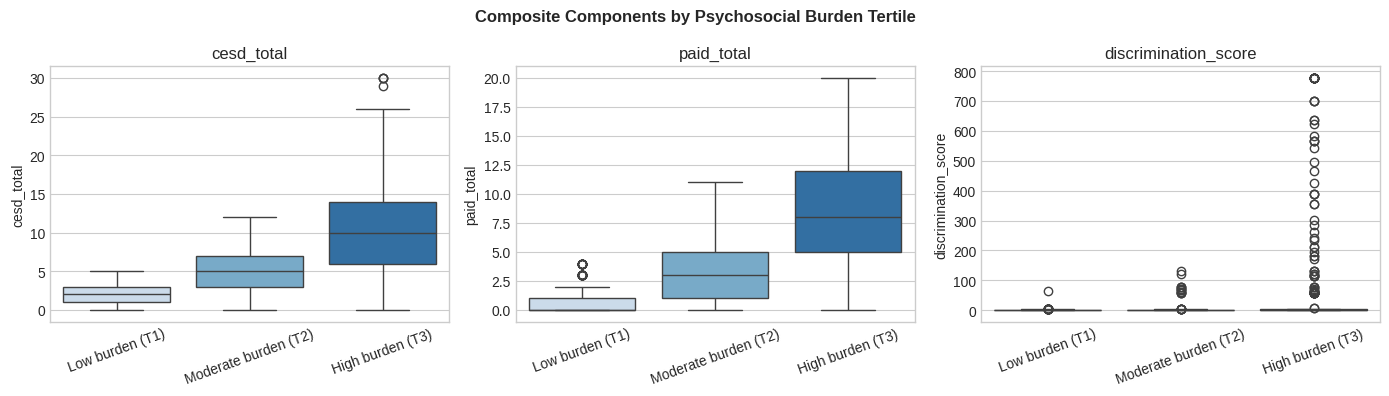

In [5]:
# ── 3c. Component distributions by tertile ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, psych_components):
    sns.boxplot(data=df, x='psych_tertile', y=col, order=TERTILE_ORDER,
                palette='Blues', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
fig.suptitle('Composite Components by Psychosocial Burden Tertile', fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Mean Glucose by Tertile

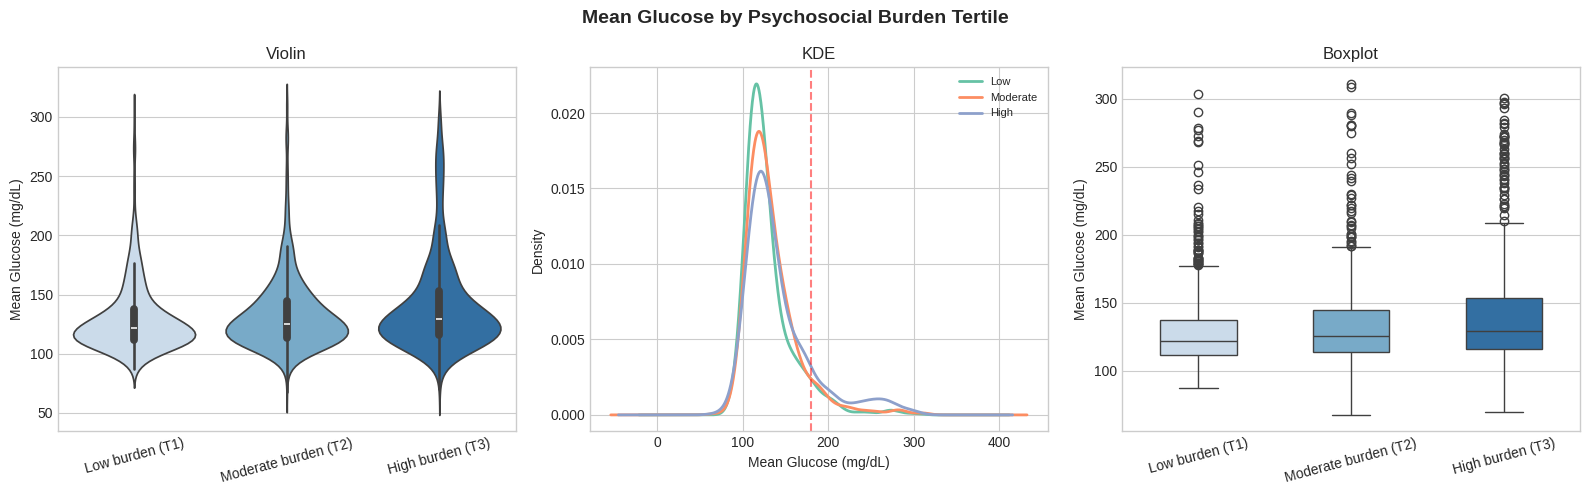

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mean Glucose by Psychosocial Burden Tertile', fontsize=14, fontweight='bold')

sns.violinplot(data=df, x='psych_tertile', y='mean_glucose',
               order=TERTILE_ORDER, palette='Blues', inner='box', ax=axes[0])
axes[0].set_title('Violin')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Glucose (mg/dL)')
axes[0].tick_params(axis='x', rotation=15)

for t in TERTILE_ORDER:
    df[df['psych_tertile'] == t]['mean_glucose'].plot.kde(
        ax=axes[1], label=t.split(' ')[0], linewidth=2)
axes[1].axvline(180, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('KDE')
axes[1].set_xlabel('Mean Glucose (mg/dL)')
axes[1].legend(fontsize=8)

sns.boxplot(data=df, x='psych_tertile', y='mean_glucose',
            order=TERTILE_ORDER, palette='Blues', width=0.5, ax=axes[2])
axes[2].set_title('Boxplot')
axes[2].set_xlabel('')
axes[2].set_ylabel('Mean Glucose (mg/dL)')
axes[2].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## 5. Statistical Tests

In [7]:
# ── 5a. Kruskal-Wallis ───────────────────────────────────────────────────
groups = [df[df['psych_tertile'] == t]['mean_glucose'].dropna().values
          for t in TERTILE_ORDER]
stat, p_kw = stats.kruskal(*groups)
print(f'Kruskal-Wallis H={stat:.3f}  p={p_kw:.2e}')

# Spearman trend
rho, p_trend = stats.spearmanr(df['psych_tertile_num'], df['mean_glucose'])
print(f'Spearman trend (tertile num vs mean glucose): rho={rho:.4f}  p={p_trend:.2e}')


Kruskal-Wallis H=40.348  p=1.73e-09
Spearman trend (tertile num vs mean glucose): rho=0.1355  p=1.89e-10


In [8]:
# ── 5b. Pairwise Mann-Whitney ────────────────────────────────────────────
from itertools import combinations
pairs = list(combinations(TERTILE_ORDER, 2))
bonf  = 0.05 / len(pairs)
print(f'Pairwise comparisons (Bonferroni alpha={bonf:.4f}):\n')
for t1, t2 in pairs:
    a = df[df['psych_tertile'] == t1]['mean_glucose'].dropna()
    b = df[df['psych_tertile'] == t2]['mean_glucose'].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    d = (b.mean() - a.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2)
    sig = '***' if p < bonf else ('*' if p < 0.05 else 'ns')
    print(f'  {t1[:6]} vs {t2[:6]}: U={u:.0f}  p={p:.4f}  d={d:+.3f}  {sig}')


Pairwise comparisons (Bonferroni alpha=0.0167):

  Low bu vs Modera: U=238634  p=0.0004  d=+0.140  ***
  Low bu vs High b: U=216596  p=0.0000  d=+0.340  ***
  Modera vs High b: U=243318  p=0.0031  d=+0.213  ***


In [9]:
# ── 5c. Composite score Spearman correlation with mean glucose ───────────
rho_c, p_c = stats.spearmanr(df['psych_burden_composite'], df['mean_glucose'])
print(f'Continuous composite rho={rho_c:.4f}  p={p_c:.2e}  n={len(df):,}')
print()
# Each component separately
for col in psych_components:
    sub = df[['mean_glucose', col]].dropna()
    rho_i, p_i = stats.spearmanr(sub['mean_glucose'], sub[col])
    print(f'  {col:<25} rho={rho_i:+.4f}  p={p_i:.4f}')


Continuous composite rho=0.1357  p=1.77e-10  n=2,193

  cesd_total                rho=+0.0123  p=0.5658
  paid_total                rho=+0.2213  p=0.0000
  discrimination_score      rho=+0.0476  p=0.0258


## 6. Study-Group Stratification

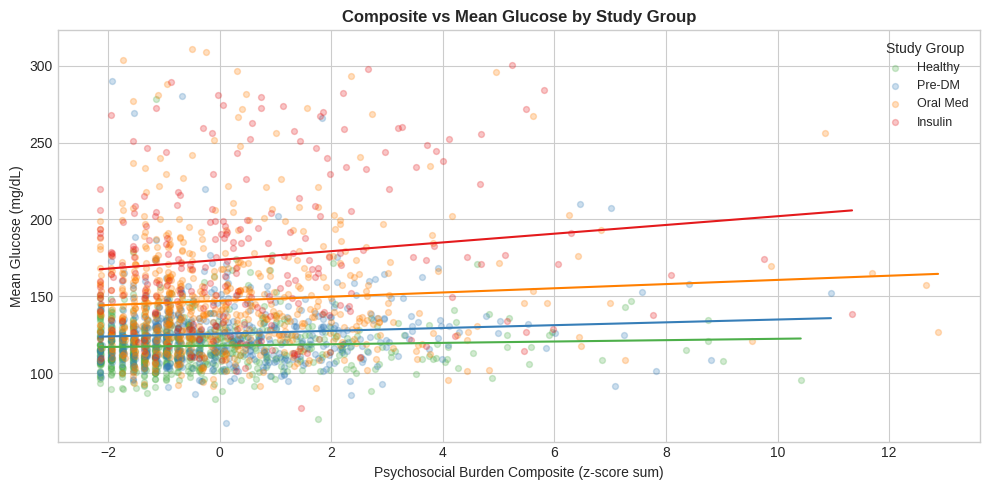

In [10]:
# Does psychosocial burden predict glucose independently of study group?
fig, ax = plt.subplots(figsize=(10, 5))
pal = {'Healthy': '#4daf4a', 'Pre-DM': '#377eb8', 'Oral Med': '#ff7f00', 'Insulin': '#e41a1c'}
for grp in STUDY_GROUP_ORDER:
    sub = df[df['study_group_label'] == grp]
    ax.scatter(sub['psych_burden_composite'], sub['mean_glucose'],
               alpha=0.25, s=18, label=grp, color=pal[grp])
    # regression line
    m, b, *_ = stats.linregress(sub['psych_burden_composite'], sub['mean_glucose'])
    xs = np.linspace(sub['psych_burden_composite'].min(), sub['psych_burden_composite'].max(), 100)
    ax.plot(xs, m*xs + b, linewidth=1.5, color=pal[grp])

ax.set_xlabel('Psychosocial Burden Composite (z-score sum)')
ax.set_ylabel('Mean Glucose (mg/dL)')
ax.set_title('Composite vs Mean Glucose by Study Group', fontweight='bold')
ax.legend(title='Study Group', fontsize=9)
plt.tight_layout()
plt.show()


## 7. Summary Table & Export

In [11]:
summary = (
    df.groupby('psych_tertile', observed=True)['mean_glucose']
    .agg(n='count', mean='mean', std='std', median='median',
         pct_gt_180=lambda x: (x > 180).mean() * 100)
    .round(2).reset_index()
)
summary.columns = ['Psychosocial Tertile', 'N', 'Mean (mg/dL)', 'SD', 'Median', '% > 180 mg/dL']
print(summary.to_string(index=False))

summary.to_csv(out_dir / '11_psychosocial_tertiles_summary.csv', index=False)
print('\nSaved 11_psychosocial_tertiles_summary.csv')


Psychosocial Tertile   N  Mean (mg/dL)     SD  Median  % > 180 mg/dL
     Low burden (T1) 731       129.670 29.410 121.710          6.430
Moderate burden (T2) 731       133.960 31.730 125.420          7.660
    High burden (T3) 731       141.700 40.530 129.580         12.590

Saved 11_psychosocial_tertiles_summary.csv


## 8. Key Findings

- **Omnibus test**: Kruskal-Wallis H = 40.3, p = 1.73e-09 — mean glucose differs significantly across the three psychosocial burden tertiles.
- **Dose-response gradient**: Mean glucose rises monotonically from Low burden T1 (129.7 mg/dL) → Moderate T2 (134.0 mg/dL) → High burden T3 (141.7 mg/dL); Spearman rho = 0.136, p = 1.89e-10.
- **All pairwise comparisons significant** after Bonferroni correction (α = 0.0167): Low vs Moderate (p=0.0004, d=+0.14), Low vs High (p < 0.0001, d=+0.34), Moderate vs High (p=0.0031, d=+0.21).
- **PAID is the dominant component**: `paid_total` (diabetes distress) drives the composite association — individual Spearman rho = +0.221, p < 0.0001. By contrast, `cesd_total` (depression) is non-significant (rho=+0.012, p=0.57) and `discrimination_score` has only a marginal association (rho=+0.048, p=0.026).
- **Continuous composite**: Spearman rho = 0.136, p = 1.77e-10 across all n=2,193 participants with complete psychosocial data.
- **Threshold exceedance**: % of daily means > 180 mg/dL escalates across tertiles — T1: 6.4%, T2: 7.7%, T3: 12.6%.
- **Interpretation**: Higher psychosocial burden — especially diabetes-specific distress (PAID) — is associated with worse glycemic control. The effect is statistically robust but modest in magnitude (d ≤ 0.34), consistent with psychosocial burden acting as a contributing factor rather than a primary driver relative to disease severity.
